In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
!find "/content/drive/MyDrive" -iname "dataset" -type d

/content/drive/MyDrive/Face_Recognition_Project/dataset


In [29]:
DATASET_DIR = "/content/drive/MyDrive/Face_Recognition_Project/dataset"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Face_Recognition_Project/model"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)      # MobileNetV2's expected input size
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
print("Classes found:", CLASS_NAMES)

Classes found: ['Alwin', 'sajan']


cell 4


In [30]:
!pip install -q pillow-heif

import pillow_heif
from PIL import Image
import pathlib

pillow_heif.register_heif_opener()

data_root = pathlib.Path(DATASET_DIR)
converted_count = 0
failed = []

for class_name in CLASS_NAMES:
    class_dir = data_root / class_name
    heic_files = list(class_dir.glob("*.HEIC")) + list(class_dir.glob("*.heic"))

    for heic_path in heic_files:
        try:
            img = Image.open(heic_path).convert("RGB")
            jpg_path = heic_path.with_suffix(".jpg")
            img.save(jpg_path, "JPEG", quality=95)
            heic_path.unlink()
            converted_count += 1
        except Exception as e:
            failed.append((str(heic_path), str(e)))

print(f"Converted {converted_count} HEIC files to JPG.")
if failed:
    print(f"\n{len(failed)} files failed to convert:")
    for path, err in failed:
        print(f"  {path}: {err}")

Converted 0 HEIC files to JPG.


Alwin: 477 images
sajan: 223 images


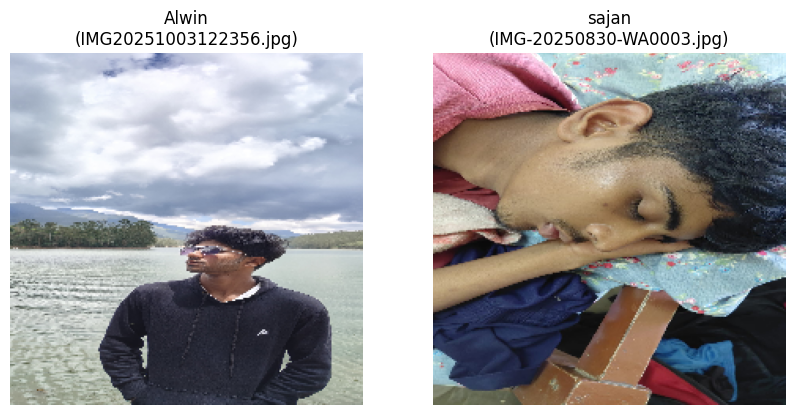

In [31]:
data_root = pathlib.Path(DATASET_DIR)

for class_name in CLASS_NAMES:
    class_dir = data_root / class_name
    n_images = len(list(class_dir.glob("*.*")))
    print(f"{class_name}: {n_images} images")

# Quick visual check — skip any file that fails to open instead of crashing
plt.figure(figsize=(10, 5))
for i, class_name in enumerate(CLASS_NAMES):
    class_dir = data_root / class_name
    shown = False
    for candidate in class_dir.glob("*.*"):
        try:
            img = tf.keras.utils.load_img(candidate, target_size=IMG_SIZE)
            plt.subplot(1, len(CLASS_NAMES), i + 1)
            plt.imshow(img)
            plt.title(f"{class_name}\n({candidate.name})")
            plt.axis("off")
            shown = True
            break
        except Exception:
            continue
    if not shown:
        print(f"WARNING: no readable image found for class '{class_name}'")
plt.show()

cell 5

In [32]:
from PIL import Image

def is_readable_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

all_paths = []
all_labels = []
skipped = []

for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = data_root / class_name
    for img_path in class_dir.glob("*.*"):
        if is_readable_image(img_path):
            all_paths.append(str(img_path))
            all_labels.append(idx)
        else:
            skipped.append(str(img_path))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total valid images: {len(all_paths)}")
print(f"Skipped (unreadable) files: {len(skipped)}")
if skipped:
    for s in skipped[:10]:
        print("  -", s)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Total valid images: 700
Skipped (unreadable) files: 0

Train: 490 | Val: 105 | Test: 105


cell 6

In [33]:
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    # decode_image handles JPEG/PNG/BMP/GIF uniformly and expand_animations=False
    # guarantees a single 3D frame instead of a 4D animation stack
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

def make_dataset(paths, labels, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
])

train_ds = make_dataset(train_paths, train_labels, shuffle=True, augment=True)
val_ds   = make_dataset(val_paths, val_labels, shuffle=False, augment=False)
test_ds  = make_dataset(test_paths, test_labels, shuffle=False, augment=False)

print("Datasets rebuilt successfully.")

Datasets rebuilt successfully.


In [34]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class weights:", class_weight_dict)
for idx, class_name in enumerate(CLASS_NAMES):
    print(f"  {class_name}: {class_weight_dict[idx]:.3f}")

Class weights: {0: np.float64(0.7335329341317365), 1: np.float64(1.5705128205128205)}
  Alwin: 0.734
  sajan: 1.571


In [35]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze the base for phase 1 training

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
EPOCHS_PHASE1 = 15

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6388 - loss: 0.7572 - val_accuracy: 0.8381 - val_loss: 0.3641
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 969ms/step - accuracy: 0.8449 - loss: 0.3668 - val_accuracy: 0.9048 - val_loss: 0.2778
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 79s 837ms/step - accuracy: 0.8612 - loss: 0.3216 - val_accuracy: 0.9048 - val_loss: 0.2352
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 858ms/step - accuracy: 0.8816 - loss: 0.2567 - val_accuracy: 0.9143 - val_loss: 0.2125
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9204 - loss: 0.1803 - val_accuracy: 0.9429 - val_loss: 0.1737
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 974ms/step - accuracy: 0.9163 - loss: 0.1886 - val_accuracy: 0.9143 - val_loss: 0.2017
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9265 - loss: 0.1892 - val_accuracy: 0.9429 - val_loss: 0.1623
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 843ms/step - accuracy: 0.9510 - loss: 0.1351 - val_accuracy: 0.9

Cell 10 — Plot training curves

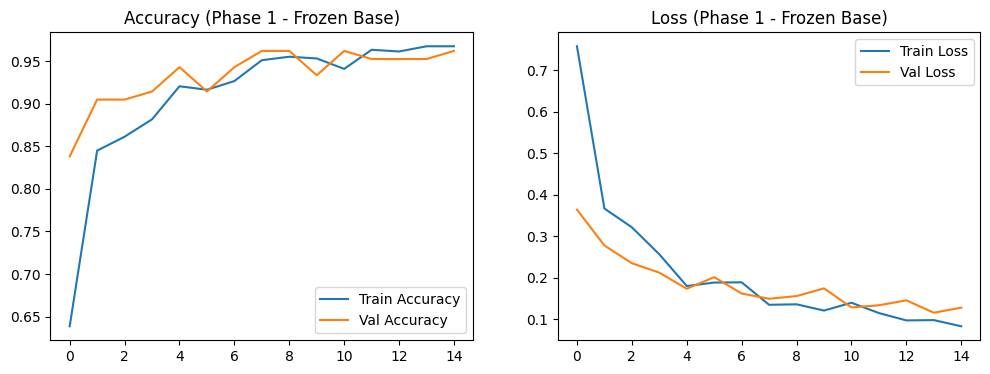

In [37]:
def plot_history(history, title_suffix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.legend()
    plt.title(f"Accuracy {title_suffix}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend()
    plt.title(f"Loss {title_suffix}")
    plt.show()

plot_history(history1, "(Phase 1 - Frozen Base)")

Cell 11 — Phase 2: fine-tune the top layers of MobileNetV2

In [38]:
base_model.trainable = True

# Freeze everything except the last ~30 layers of the base model
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_PHASE2 = 10

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8735 - loss: 0.2325 - val_accuracy: 0.9524 - val_loss: 0.1178
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 791ms/step - accuracy: 0.9061 - loss: 0.1903 - val_accuracy: 0.9524 - val_loss: 0.1212
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 83s 727ms/step - accuracy: 0.9265 - loss: 0.1579 - val_accuracy: 0.9429 - val_loss: 0.1346
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 984ms/step - accuracy: 0.9469 - loss: 0.1346 - val_accuracy: 0.9429 - val_loss: 0.1377


Cell 12 — Evaluate on the held-out test set

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9333 - loss: 0.1846

Test Accuracy: 0.9333
Test Loss: 0.1846

Classification Report:
              precision    recall  f1-score   support

       Alwin       0.97      0.93      0.95        72
       sajan       0.86      0.94      0.90        33

    accuracy                           0.93       105
   macro avg       0.92      0.93      0.92       105
weighted avg       0.94      0.93      0.93       105



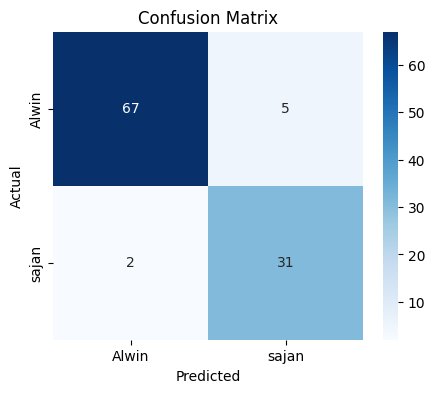

In [39]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Detailed classification report + confusion matrix
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Saving 20220925_113554.jpg to 20220925_113554.jpg


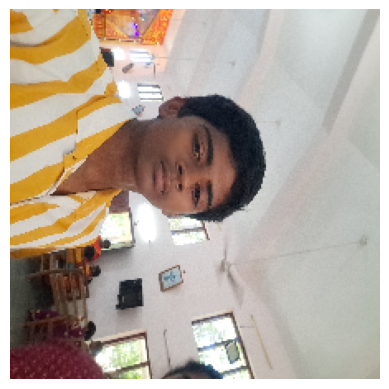

Prediction: sajan (confidence: 99.79%)

Full probabilities: {'Alwin': np.float32(0.0021306714), 'sajan': np.float32(0.99786925)}


In [40]:
from google.colab import files
import numpy as np

CONFIDENCE_THRESHOLD = 0.75  # we'll fine-tune this after seeing Cell 12's results

uploaded = files.upload()  # this opens a file picker — choose an image from your computer

for filename in uploaded.keys():
    img = tf.keras.utils.load_img(filename, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    preds = model.predict(img_array, verbose=0)[0]
    best_idx = np.argmax(preds)
    confidence = preds[best_idx]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if confidence < CONFIDENCE_THRESHOLD:
        print(f"Prediction: Unknown Person (best guess was {CLASS_NAMES[best_idx]} at {confidence:.2%}, below threshold)")
    else:
        print(f"Prediction: {CLASS_NAMES[best_idx]} (confidence: {confidence:.2%})")

    print(f"\nFull probabilities: {dict(zip(CLASS_NAMES, preds))}")

In [41]:
import os
import json

MODEL_SAVE_DIR = "/content/drive/MyDrive/Face_Recognition_Project/model"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

model_path = os.path.join(MODEL_SAVE_DIR, "face_recognition_model.keras")
model.save(model_path)
print(f"Model saved to: {model_path}")

with open(os.path.join(MODEL_SAVE_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)
print("Class names saved.")

# Verify the files actually landed
print("\nFiles in model folder:")
print(os.listdir(MODEL_SAVE_DIR))

Model saved to: /content/drive/MyDrive/Face_Recognition_Project/model/face_recognition_model.keras
Class names saved.

Files in model folder:
['face_recognition_model.keras', 'class_names.json']
